# Does the magnetisation do what the timeline says?

[`01_build.ipynb`](01_build.ipynb) checked the sequence against arithmetic: `sc.kspace` says the
`center_line` readout lands exactly `TI` after the inversion's effective centre, for both
orderings. Everything it asserted would still hold for a sequence whose inversion **did not
invert**, so this notebook measures the physics instead:

1. **the recovery curve**, swept through a real shot: the signal at k = 0 has to cross zero at
   $\mathrm{TI} = T_1\ln 2$. That one measurement validates the inversion, `time_to_center` and
   the TI placement together, and no arithmetic in `01` can make it.
2. **the images**, and what the line ordering costs.

Two things `01`'s protocol already encodes, both found by measurement and both left here as notes
rather than as sections:

| | |
|---|---|
| **the inversion is a hard 180°, not the module's adiabatic default** | MRzero applies a pulse as an instantaneous rotation by the integral of its envelope. That is exact for a block pulse and fine for a sinc; an adiabatic pulse inverts through a frequency sweep instead, and a 10 ms hyperbolic secant integrates to **289°**, so in this simulator it does not invert at all. (`use='inversion'` also arrives as `PulseUsage.UNDEF`, because MRzero has no such member — harmless, since the simulation ignores usage and a pulse inverts because of its flip angle.) `IRPrep` keeps `'hypsec'` as its default because that is right on a scanner, and `time_to_center` absorbs the 4.5 ms difference without any other number in the timeline moving. |
| **`DUMMY_SHOTS = 5`** | interleaved segmentation gives every shot a comb in k-space, so a shot-to-shot signal difference is a periodic modulation and therefore a replica of the object at FOV/4. Measured spread across shots: 296 % with none, 48 % with one, 8.7 % with three. It is **not** a gradient-spoiling problem — turning the extra spoiler axes off moves the image background by 0.01 %. |

**Needs `seqcraft[sim,recon]`** — MRzeroCore, torch and sigpy — and the same ~19 MB BrainWeb
phantom `gre_2d/02` downloads into `examples/data/`.

In [1]:
import tempfile
import urllib.request
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import MRzeroCore as mr0
import numpy as np
import pypulseq as pp
import torch

import seqcraft as sc

plt.rcParams['figure.dpi'] = 56          # keeps the committed notebook a readable size

SEQ_DIR = Path('seq')
nominal = np.load(SEQ_DIR / 'mprage_2d_nominal.npz')

MATRIX = tuple(int(v) for v in nominal['matrix'])
FOV_MM = tuple(float(v) for v in nominal['fov_mm'])
THICKNESS_MM = float(nominal['thickness_mm'])
CENTER_LINE = int(nominal['center_line'])
TI_S = float(nominal['ti_s'])
TURBO = int(nominal['turbo'])
FLIP_DEG = float(nominal['flip_deg'])
BANDWIDTH_HZ_PX = float(nominal['bandwidth_hz_px'])
INVERSION_PULSE = str(nominal['inversion_pulse'])
INVERSION_DURATION_S = float(nominal['inversion_duration_s'])
NX, NY = MATRIX

segmentations = {name: [tuple(int(v) for v in segment) for segment in nominal[f'segments_{name}']]
                 for name in ('linear', 'centric')}

opts = pp.Opts(
    max_grad=40, grad_unit='mT/m',
    max_slew=150, slew_unit='T/m/s',
    B0=3.0,
    rf_dead_time=100e-6,
    rf_ringdown_time=30e-6,
    adc_dead_time=10e-6,
)
grad_raster = sc.Raster(opts.grad_raster_time)

inv = sc.modules.IRPrep(opts=opts, thickness_mm=None, pulse=INVERSION_PULSE,
                        duration_s=INVERSION_DURATION_S, spoil_voxel_mm=THICKNESS_MM)
gre = sc.modules.GRE2D(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM,
                       flip_deg=FLIP_DEG, bandwidth_hz_px=BANDWIDTH_HZ_PX)

print(f'{NX} x {NY}, {len(segmentations["centric"])} shots of {TURBO}, TI {TI_S * 1e3:.0f} ms')
print(f'inversion: {INVERSION_PULSE}, {INVERSION_DURATION_S * 1e3:.1f} ms, centre '
      f'{inv.time_to_center() * 1e3:.3f} ms into its block')

D:\MIniconda\envs\NUM\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


D:\MIniconda\envs\NUM\Lib\site-packages\sigpy\config.py:27: UserWarning: Importing cupy.cuda.cudnn failed. For more details, see the error stack below:
DLL load failed while importing cudnn: The specified module could not be found.
  warnings.warn(


128 x 128, 4 shots of 32, TI 800 ms
inversion: block, 1.0 ms, centre 0.600 ms into its block


---
## 1. The phantom

The same BrainWeb slab and eight-element receive ring as `gre_2d/02`, for the same two reasons: a
one-voxel-thick phantom reads a slice-select gradient as complete dephasing and returns *exactly
zero* signal, so the phantom is a **slab** spanning the slice; and a single uniform coil measures
one number per k-space sample.

This phantom has two tissue classes in the slice, at $T_1 \approx 0.86$ s and $1.58$ s. The null
at $\mathrm{TI}/\ln 2 = 1.15$ s falls **between** them, so they end up on opposite sides of the
crossing and the magnitude image shows the largest contrast the sequence can produce.

In [2]:
PHANTOM_URL = ('https://github.com/MRsources/MRzero-Core/raw/main/'
               'documentation/playground_mr0/subject05.npz')
PHANTOM = Path('../data/subject05.npz')

if not PHANTOM.exists():
    PHANTOM.parent.mkdir(parents=True, exist_ok=True)
    print(f'downloading {PHANTOM_URL} -> {PHANTOM} (~19 MB, once)')
    urllib.request.urlretrieve(PHANTOM_URL, PHANTOM)

NZ, N_COILS = 4, 8


def coil_ring(nx, ny, nz, n_coils=N_COILS):
    """A ring of `n_coils` surface coils around the object, as complex sensitivities."""
    gx, gy = np.meshgrid(np.linspace(-1, 1, nx), np.linspace(-1, 1, ny), indexing='ij')
    sens = np.stack([
        np.exp(-((gx - 1.5 * np.cos(a)) ** 2 + (gy - 1.5 * np.sin(a)) ** 2) / 1.5)
        * np.exp(1j * np.arctan2(gy - np.sin(a), gx - np.cos(a)))
        for a in np.arange(n_coils) * 2 * np.pi / n_coils
    ]).astype(np.complex64)
    return torch.tensor(np.repeat(sens[:, :, :, None], nz, axis=3))


whole = mr0.VoxelGridPhantom.load(PHANTOM).interpolate(NX, NX, 128)
phantom = whole.slices(list(range(64 - NZ // 2, 64 + NZ - NZ // 2)))
# slices() leaves the slab where it was in the volume.  Put it at isocentre, which is where the
# sequence excites -- otherwise the slice profile selects the wrong tissue, or none at all, and
# the symptom is a dark image rather than an error.
phantom.affine[2, 3] = -0.5 * NZ * float(phantom.affine[2, 2])
phantom.coil_sens = coil_ring(NX, NX, NZ)
data = phantom.build()

mid = NZ // 2
t1_map = phantom.T1[:, :, mid].numpy().T
brain = t1_map > 0.2

print(f'{tuple(phantom.PD.shape)} voxels, {N_COILS} coils')
print(f'T1 in the slice: {t1_map[brain].min():.2f} .. {t1_map[brain].max():.2f} s')
print(f'TI = {TI_S:.2f} s nulls T1 = {TI_S / np.log(2):.2f} s')

(128, 128, 4) voxels, 8 coils
T1 in the slice: 0.84 .. 4.16 s
TI = 0.80 s nulls T1 = 1.15 s


---
## 2. `to_grid`, and why it reads the labels

In `gre_2d/02` the *n*-th block of samples belonged to `lines[n]`: acquisition order and k-space
order were the same list. **Segmentation breaks that.** Shot 0 acquires lines 64, 60, 68, 56 …,
shot 1 acquires 65, 61, 69 …, and the file's block order is neither.

The `LIN` label is the independent record — `GRE2DTR` emits one per acquired readout — so the file
itself says where each block of samples belongs. Reading it back rather than reconstructing the
ordering from the segmentation is what makes the label load-bearing instead of decorative.

In [3]:
def lin_labels(path):
    """The LIN label of every acquired readout, read back out of the written file."""
    seq = pp.Sequence(system=opts)
    seq.read(str(path))
    return [int(v) for v in np.atleast_1d(np.asarray(
        seq.evaluate_labels(evolution='adc')['LIN']))]


def to_grid(signal, lines, matrix=MATRIX):
    """Scatter one readout per entry of `lines` into a (coils, ny, nx) array."""
    nx, ny = matrix
    samples = np.asarray(signal).reshape(len(lines), nx, -1)     # (readout, sample, coil)
    grid = np.zeros((samples.shape[2], ny, nx), dtype=np.complex64)
    grid[:, list(lines), :] = samples.transpose(2, 0, 1)
    return grid


def ifft2c(ksp):
    return np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(ksp, axes=(-2, -1)),
                                        norm='ortho'), axes=(-2, -1))


def rss(image):
    return np.sqrt((np.abs(image) ** 2).sum(0))


def simulate(path, payload):
    """Import the written .seq and simulate it, so the check is on the file."""
    seq = mr0.Sequence.import_file(str(path))
    graph = mr0.compute_graph(seq, payload, max_state_count=200, min_state_mag=1e-4)
    return np.asarray(mr0.execute_graph(graph, seq, payload, min_emitted_signal=1e-4,
                                        min_latent_signal=1e-5, print_progress=False))


for name, segments in segmentations.items():
    from_file = lin_labels(SEQ_DIR / f'mprage_2d_{name}.seq')
    from_notebook = [line for segment in segments for line in segment]
    assert from_file == from_notebook, f'{name}: the file and the segmentation disagree'
    print(f'{name:8s} {len(from_file)} LIN labels, first eight {from_file[:8]}   '
          f'(acquisition order is not k-space order)')

linear   128 LIN labels, first eight [0, 4, 8, 12, 16, 20, 24, 28]   (acquisition order is not k-space order)
centric  128 LIN labels, first eight [64, 60, 68, 56, 72, 52, 76, 48]   (acquisition order is not k-space order)


---
## 3. The recovery curve, through the real sequence

One shot at a time — inversion, wait, a centric train — with the signal read at `center_line`,
which is the readout TI is defined against, and against a single voxel per tissue so the curve is
the physics rather than a mixture.

**This is the acceptance test for the timing.** If TI were referenced to the inversion block's
start rather than to its effective centre, or if `time_to_center_line` were dropped, the curve
would be *shifted by a constant* — invisible against intuition and obvious against
$1-2e^{-\mathrm{TI}/T_1}$.

The probe sequences go to a scratch directory rather than into `seq/`: they are a measurement,
not an output of this example.

In [4]:
segment = segmentations['centric'][0]
SHOT_TI = np.round(np.linspace(0.1, 2.2, 12), 4)
tissue = {'white matter': 0.86, 'grey matter': 1.58, 'CSF': 4.0}


def one_voxel(t1_s):
    """
    A single voxel of the given T1.

    Python floats rather than numpy scalars: a numpy value makes ``voxel_pos`` float64, which
    promotes the simulator's magnetisation to complex128 and then fails against its own complex64
    coil array -- a dtype error a long way from its cause.
    """
    built = mr0.CustomVoxelPhantom(
        pos=[[0.0, 0.0, 0.0]], PD=[1.0], T1=[float(t1_s)], T2=[0.1], T2dash=[0.05], D=[0.0],
        voxel_size=0.01, voxel_shape='box',
    ).build()
    built.B0 = built.B0.float()
    built.B1 = built.B1.float()
    return built


def one_shot(ti_s, scratch):
    """One MPRAGE shot at the given TI: the composition `01` wrote, with no class around it."""
    offset = float(grad_raster.ceil(
        inv.time_to_center() + ti_s - gre.time_to_center_line(lines=segment)))
    tree = sc.LogicBlock('shot')
    tree.add(0.0, inv())
    tree.add(offset, gre(lines=segment, dummies=0))
    path = Path(scratch) / f'shot_{round(ti_s * 1e3)}.seq'
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', sc.SeqCraftWarning)
        sc.compile(tree, opts, name='shot').write(str(path))
    return path


readout = segment.index(CENTER_LINE)
through_shot = {}
with tempfile.TemporaryDirectory(prefix='mprage-probe-') as scratch:
    paths = [one_shot(float(ti), scratch) for ti in SHOT_TI]
    for label, t1 in tissue.items():
        voxel = one_voxel(t1)
        through_shot[label] = np.asarray([
            simulate(path, voxel).reshape(len(segment), NX, -1)[readout, NX // 2, 0]
            for path in paths
        ])
print(f'{len(SHOT_TI)} inversion times x {len(tissue)} tissues, through a real '
      f'{TURBO}-line shot')

12 inversion times x 3 tissues, through a real 32-line shot


tissue             T1   null, ideal   null, measured
white matter     0.86        0.596s          0.604 s
grey matter      1.58        1.095s          1.101 s
CSF              4.00        2.773s beyond the sweep


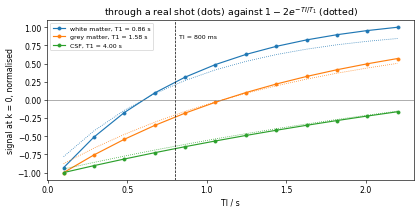

In [5]:
def crossing(curve, tis=SHOT_TI):
    """Linear interpolation to the first sign change, or None."""
    changes = np.where(np.diff(np.sign(curve)))[0]
    if not len(changes):
        return None
    i = changes[0]
    return float(tis[i] + (tis[i + 1] - tis[i]) * (-curve[i]) / (curve[i + 1] - curve[i]))


fig, ax = plt.subplots(figsize=(7.6, 3.9))
for index, (label, t1) in enumerate(tissue.items()):
    curve = np.real(through_shot[label])
    ax.plot(SHOT_TI, curve / np.abs(curve).max(), 'o-', ms=4, color=f'C{index}',
            label=f'{label}, T1 = {t1:.2f} s')
    ax.plot(SHOT_TI, 1 - 2 * np.exp(-SHOT_TI / t1), ':', lw=1.0, color=f'C{index}')
ax.axvline(TI_S, color='k', lw=0.9, ls='--')
ax.text(TI_S, 0.85, f'  TI = {TI_S * 1e3:.0f} ms', fontsize=8)
ax.axhline(0, color='0.5', lw=0.8)
ax.set(xlabel='TI / s', ylabel='signal at k = 0, normalised',
       title='through a real shot (dots) against $1-2e^{-TI/T_1}$ (dotted)')
ax.legend(fontsize=8)
fig.tight_layout()

print(f'{"tissue":14s} {"T1":>6s} {"null, ideal":>13s} {"null, measured":>16s}')
for label, t1 in tissue.items():
    measured = crossing(np.real(through_shot[label]))
    shown = 'beyond the sweep' if measured is None else f'{measured:.3f} s'
    print(f'{label:14s} {t1:6.2f} {t1 * np.log(2):12.3f}s {shown:>16s}')

The two brain tissues null within a few milliseconds of $T_1\ln 2$, which is the whole timing
chain checked at once: the inversion inverts, `time_to_center` points at the right instant, and
`time_to_center_line` puts k = 0 where the arithmetic said it would.

The measured curve sits slightly **below** the ideal one at long TI, and that is not a placement
error: the train's own excitations have already spent some of the longitudinal magnetisation by
the time k = 0 is reached, even at 8°. The next section is the same effect seen as contrast rather
than as a scale.

---
## 4. The images, and what the ordering costs

The two `.seq` files `01` wrote: the same 128 lines, the same TI, the same four shots — and two
orderings *within* each shot.

Centric acquires k = 0 **first**, at the point on the recovery curve the TI was chosen for. Linear
acquires it sixteen repetitions in, after the train has already driven the magnetisation down.
Both are legal, both produce an image, and the difference is not a scale factor: the low spatial
frequencies carry a different weighting relative to the high ones, so what changes is the
**contrast**.

In [6]:
ksp, images = {}, {}
for name in segmentations:
    path = SEQ_DIR / f'mprage_2d_{name}.seq'
    ksp[name] = to_grid(simulate(path, data), lin_labels(path))
    images[name] = rss(ifft2c(ksp[name]))
    print(f'{name:8s} {ksp[name].shape} (coils, ny, nx)')

import sigpy.mri as smri

mps = smri.app.EspiritCalib(ksp['centric'], show_pbar=False).run()
recon = {name: np.abs(smri.app.TotalVariationRecon(k, mps, lamda=2e-3, max_iter=120,
                                                   show_pbar=False).run())
         for name, k in ksp.items()}
print('coil maps and reconstructions done')

linear   (8, 128, 128) (coils, ny, nx)


centric  (8, 128, 128) (coils, ny, nx)


coil maps and reconstructions done


signal at the centre of the image, centric / linear: 1.137
mean over the whole image:                           1.129

The two ratios differ, which is the point: centric is not linear times a constant, and
where they differ is tissue-dependent because the train drives each T1 differently.


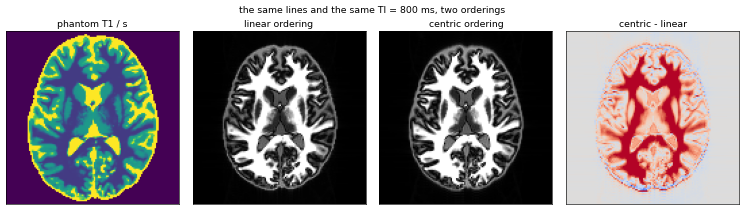

In [7]:
vmax = 0.6 * max(image.max() for image in images.values())
fig, axes = plt.subplots(1, 4, figsize=(13.5, 3.7))
axes[0].imshow(t1_map, origin='lower', cmap='viridis', vmin=0.5, vmax=2.5)
axes[0].set(title='phantom T1 / s', xticks=[], yticks=[])
for ax, name in zip(axes[1:3], ('linear', 'centric')):
    ax.imshow(images[name], origin='lower', cmap='gray', vmin=0, vmax=vmax)
    ax.set(title=f'{name} ordering', xticks=[], yticks=[])
difference = images['centric'] - images['linear']
limit = 0.7 * np.abs(difference).max()
axes[3].imshow(difference, origin='lower', cmap='coolwarm', vmin=-limit, vmax=limit)
axes[3].set(title='centric - linear', xticks=[], yticks=[])
fig.suptitle(f'the same lines and the same TI = {TI_S * 1e3:.0f} ms, two orderings', y=1.0)
fig.tight_layout()

centre = images['centric'][NY // 2, NX // 2] / images['linear'][NY // 2, NX // 2]
print(f'signal at the centre of the image, centric / linear: {centre:.3f}')
print(f'mean over the whole image:                           '
      f'{images["centric"].mean() / images["linear"].mean():.3f}')
print()
print('The two ratios differ, which is the point: centric is not linear times a constant, and')
print('where they differ is tissue-dependent because the train drives each T1 differently.')

### Is it MPRAGE contrast?

The check that this is the image the protocol asked for rather than merely an image. The two
tissue classes sit on opposite sides of the null, so the predicted magnitude ratio is
$|1-2e^{-\mathrm{TI}/T_1}|$ for each.

It has to be measured in a **central box**: the receive ring's sensitivity varies by more across
the image than the tissues do, so a whole-brain comparison would be a picture of the coil array
rather than of the contrast. [`../mp2rage_2d/`](../mp2rage_2d/01_build.ipynb) removes that term
instead of avoiding it, which is the reason that sequence exists.

In [8]:
box = np.zeros_like(brain)
box[NY // 2 - 24:NY // 2 + 24, NX // 2 - 24:NX // 2 + 24] = True
classes = {'white': (t1_map < 1.1) & brain & box, 'grey': (t1_map > 1.3) & brain & box}

print(f'{"class":8s} {"voxels":>8s} {"median T1":>11s} {"predicted":>11s} '
      f'{"linear":>10s} {"centric":>10s}')
predicted, measured = {}, {}
for label, mask in classes.items():
    t1 = float(np.median(t1_map[mask]))
    predicted[label] = abs(1 - 2 * np.exp(-TI_S / t1))
    measured[label] = {name: float(recon[name][mask].mean()) for name in recon}
    print(f'{label:8s} {int(mask.sum()):8d} {t1:10.2f}s {predicted[label]:11.3f} '
          f'{measured[label]["linear"]:10.3f} {measured[label]["centric"]:10.3f}')

print()
print(f'predicted white/grey ratio {predicted["white"] / predicted["grey"]:.3f}')
for name in recon:
    print(f'measured, {name:8s}       '
          f'{measured["white"][name] / measured["grey"][name]:.3f}')
print()
print('Both orderings put white matter more than twice as bright as grey, which is the MPRAGE')
print('contrast -- and both far above the ratio a single-point recovery predicts.  That gap is the')
print('train: 32 excitations drive a short T1 and a long one to different places, so the turbo')
print('factor and the flip angle are part of the contrast rather than only of the timing.')

class      voxels   median T1   predicted     linear    centric
white         994       0.86s       0.214      8.467      9.757
grey         1113       1.58s       0.206      4.106      4.755

predicted white/grey ratio 1.036
measured, linear         2.062
measured, centric        2.052

Both orderings put white matter more than twice as bright as grey, which is the MPRAGE
contrast -- and both far above the ratio a single-point recovery predicts.  That gap is the
train: 32 excitations drive a short T1 and a long one to different places, so the turbo
factor and the flip angle are part of the contrast rather than only of the timing.


---
## What this notebook established

| | |
|---|---|
| the null point lands at $T_1\ln 2$ | to a few milliseconds, through a real shot — which validates the inversion, `time_to_center` and the TI placement in one measurement |
| the recovery curve sits slightly below the ideal one at long TI | because the train has already spent some of the magnetisation by the time k = 0 arrives |
| `LIN` is what makes segmented data reconstructable | acquisition order and k-space order are different lists here, and the file is the record of which is which |
| ordering changes the **contrast**, not the gain | centric and linear differ by a tissue-dependent amount |
| a single-point recovery formula under-predicts the contrast | the turbo factor and the flip angle belong to the contrast, not only to the timing |

And two things measured, then folded into `01`'s protocol rather than left as figures here: the
adiabatic inversion this simulator cannot represent, and the five dummy shots the shot-to-shot
equilibrium needs.